### 描画ツールの違い
- matplotlib
  - 描画形式：静的
  - サクッと描画するならこちらがよい
  - 入力はList
- plotly
  - 描画形式：インタラクティブ(HTMLベース)
  - jupyternotebook上で、色々確認したい場合はこっちのほうがよい
  - 入力はdf
- seaborn
  - ヒートマップ、ヒストグラムなど、統計的な描画機能がそろっている
  - 入力はList,dfどちらもOK


---

#### matplotlib tips

#### 基本
| 内容         | コード例                                          |
| ---------- | --------------------------------------------- |
| 図と軸の作成     | `fig, ax = plt.subplots()`                    |
| グラフ表示      | `plt.show()`                                  |
| タイトルの設定    | `ax.set_title("タイトル")`                        |
| 軸ラベルの設定    | `ax.set_xlabel("X軸")` / `ax.set_ylabel("Y軸")` |
| グリッド表示     | `ax.grid(True)`                               |
| 凡例の表示      | `ax.legend()`（`label="..."` をプロット時に指定）        |
| 線の色・マーカー指定 | `color='r', linestyle='--', marker='o'` など    |

#### 表示調整
| 内容             | コード例                                                                    |
| -------------- | ----------------------------------------------------------------------- |
| レイアウト調整（重なり防止） | `plt.tight_layout()`                                                    |
| 図サイズの変更        | `plt.figure(figsize=(8, 4))` or `fig, ax = plt.subplots(figsize=(8,4))` |
| 軸の範囲設定         | `ax.set_xlim(xmin, xmax)` / `ax.set_ylim(ymin, ymax)`                   |
| 軸のスケール変更（対数など） | `ax.set_xscale('log')` / `'linear'`, `'log'`, `'symlog'`, `'logit'`     |
| 文字サイズ調整        | `fontsize=14` などを `title`, `xlabel`, `ylabel` などに渡す                     |
| 軸ラベルの回転        | `plt.xticks(rotation=45)`                                               |

#### グラフ種類
| グラフの種類     | コード例                                   |
| ---------- | -------------------------------------- |
| 折れ線グラフ     | `ax.plot(x, y, label="折れ線")`           |
| 散布図        | `ax.scatter(x, y)`                     |
| 棒グラフ       | `ax.bar(x, y)`                         |
| ヒストグラム     | `ax.hist(data, bins=30)`               |
| ヒートマップ     | `ax.imshow(data, cmap='viridis')`      |
| 箱ひげ図       | `ax.boxplot(data)`                     |
| 複数グラフの同時表示 | `fig, (ax1, ax2) = plt.subplots(1, 2)` |

#### カスタム　見た目
| 内容             | コード例                                                 |
| -------------- | ---------------------------------------------------- |
| 線のスタイル         | `'--'`（破線）, `'-.'`, `':'`, `'-'`（実線）                 |
| カラーマップ（ヒートマップ） | `cmap='coolwarm'`, `'viridis'`, `'plasma'`, `'gray'` |
| 凡例の位置指定        | `ax.legend(loc='upper right')`                       |
| 枠線の非表示         | `ax.spines['top'].set_visible(False)` など             |
| 縦横比の固定         | `ax.set_aspect('equal')`                             |

#### その他
| 内容                | コード例                                                               |
| ----------------- | ------------------------------------------------------------------ |
| プロットを画像として保存      | `plt.savefig("plot.png", dpi=300, bbox_inches='tight')`            |
| インラインで複数図を並べる     | Jupyterでは `%matplotlib inline` + `plt.figure()`を複数使う               |
| 背景色の変更            | `ax.set_facecolor('lightgray')`                                    |
| 軸目盛のカスタマイズ        | `ax.set_xticks([0, 1, 2])` / `ax.set_xticklabels(['A', 'B', 'C'])` |
| データラベルの追加（棒グラフなど） | `for i, v in enumerate(y): ax.text(i, v, str(v))`                  |


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

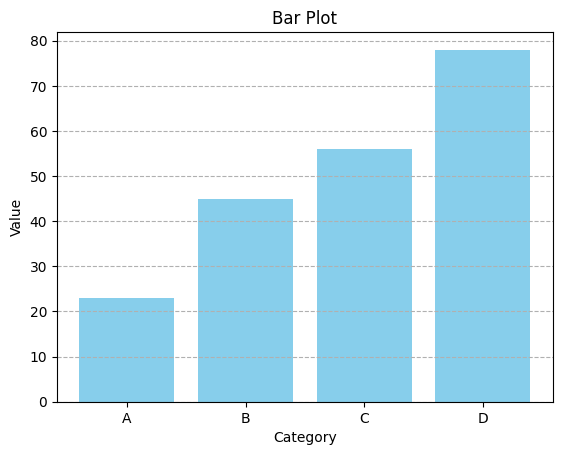

In [34]:
categories = ['A', 'B', 'C', 'D']
values = [23, 45, 56, 78]

plt.bar(categories, values, color='skyblue')
plt.title('Bar Plot')
plt.xlabel('Category')
plt.ylabel('Value')
plt.grid(True, axis='y', linestyle='--')
plt.show()

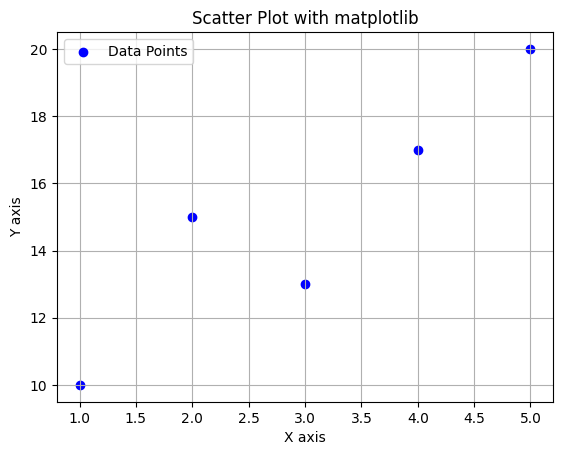

In [35]:
x = [1, 2, 3, 4, 5]
y = [10, 15, 13, 17, 20]

plt.scatter(x, y, color='blue', marker='o', label='Data Points')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.title('Scatter Plot with matplotlib')
plt.legend()
plt.grid(True)
plt.show()


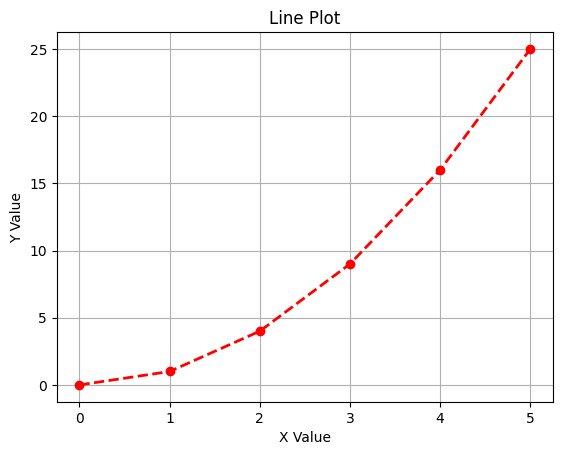

In [36]:
x = [0, 1, 2, 3, 4, 5]
y = [0, 1, 4, 9, 16, 25]

plt.plot(x, y, color='red', linewidth=2, linestyle='--', marker='o')
plt.title('Line Plot')
plt.xlabel('X Value')
plt.ylabel('Y Value')
plt.grid(True)
plt.show()

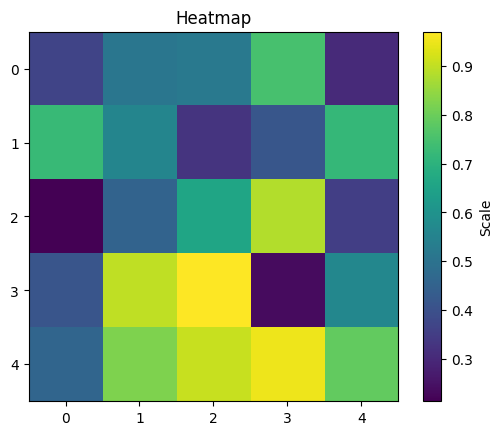

In [37]:
data = np.random.rand(5, 5)  # 5x5 の乱数行列

plt.imshow(data, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Scale')
plt.title('Heatmap')
plt.xticks(range(5))
plt.yticks(range(5))
plt.show()

---
#### seaborn
- 入力形式はList,dataframeどちらでも受け付ける
- 主な使用ケース
  - ヒートマップ
  - ヒストグラム

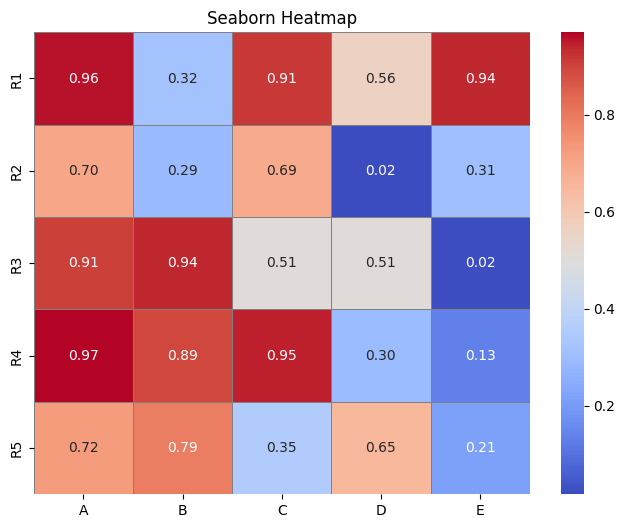

In [38]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 5x5 のランダムなデータフレームを作成
data = np.random.rand(5, 5)
df = pd.DataFrame(data, columns=['A', 'B', 'C', 'D', 'E'], index=['R1', 'R2', 'R3', 'R4', 'R5'])
# 二次元のListでもOK
# df = [[0, 1, 2], [3, 4, 5]]

# ヒートマップ描画
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, linecolor='gray')
plt.title("Seaborn Heatmap")
plt.show()


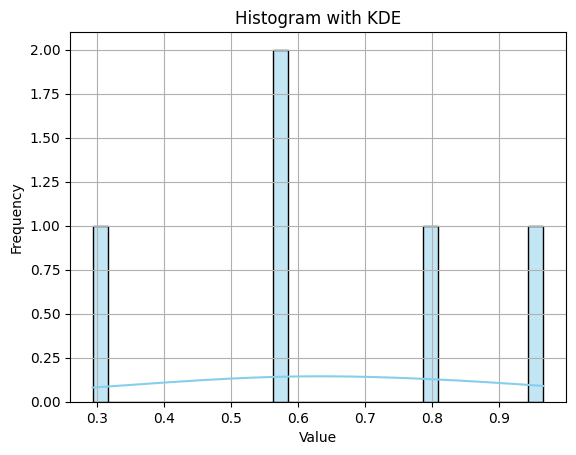

In [39]:
# データ生成（正規分布に従う乱数）
# data = np.random.randn(1000)
data = np.random.rand(5, 5)
df = pd.DataFrame(data, columns=['A', 'B', 'C', 'D', 'E'], index=['R1', 'R2', 'R3', 'R4', 'R5'])

# ヒストグラムを描画
sns.histplot(df, x='A', bins=30, kde=True, color='skyblue')

plt.title('Histogram with KDE')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

---
### plotly

#### 基本
| 内容             | コード例                                                     |
| -------------- | -------------------------------------------------------- |
| グラフの表示         | `fig.show()`                                             |
| データフレームからグラフ作成 | `fig = px.scatter(df, x='x_col', y='y_col')`             |
| グラフのタイトル設定     | `fig.update_layout(title='グラフのタイトル')`                    |
| 軸ラベルの設定        | `fig.update_layout(xaxis_title='X軸', yaxis_title='Y軸')`  |
| グラフの保存         | `fig.write_image("plot.png")`                            |
| レイアウト調整        | `fig.update_layout(margin=dict(l=50, r=50, t=50, b=50))` |

#### グラフ
| グラフの種類         | コード例                                                                                                     |
| -------------- | -------------------------------------------------------------------------------------------------------- |
| 散布図（2D）        | `fig = px.scatter(df, x='sepal_width', y='sepal_length')`                                                |
| 折れ線グラフ         | `fig = px.line(df, x='year', y='gdpPercap')`                                                             |
| 棒グラフ（縦・横）      | `fig = px.bar(df, x='day', y='total_bill')`                                                              |
| ヒストグラム         | `fig = px.histogram(df, x="total_bill", nbins=30)`                                                       |
| ヒートマップ         | `fig = px.imshow(df.corr(), text_auto=True)`                                                             |
| 箱ひげ図（Box Plot） | `fig = px.box(df, x="day", y="total_bill", color="sex")`                                                 |
| 散布図行列（ペアプロット）  | `fig = px.scatter_matrix(df, dimensions=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])` |
| 地図（Choropleth） | `fig = px.choropleth(df, locations="iso_alpha", color="lifeExp")`                                        |

#### レイアウト類の調整
| 内容            | コード例                                                                               |
| ------------- | ---------------------------------------------------------------------------------- |
| 軸ラベルのフォント調整   | `fig.update_layout(xaxis_title_font=dict(family='Arial', size=14, color='black'))` |
| 軸の範囲設定        | `fig.update_xaxes(range=[0, 10])`                                                  |
| 凡例の位置変更       | `fig.update_layout(legend=dict(x=0.8, y=0.9))`                                     |
| 軸目盛の表示・非表示    | `fig.update_xaxes(showgrid=False, zeroline=False)`                                 |
| 背景色の変更        | `fig.update_layout(plot_bgcolor='lightgray')`                                      |
| ツールチップのカスタマイズ | `fig.update_traces(hoverinfo='x+y+text', hovertemplate="%{x} - %{y}")`             |

#### インタラクティブの制御
| 内容               | コード例                                                                   |
| ---------------- | ---------------------------------------------------------------------- |
| ズーム・パン機能を無効化     | `fig.update_layout(dragmode=False)`                                    |
| ヒートマップのツールチップ表示  | `fig.update_traces(hovertemplate='x: %{x}<br>y: %{y}<br>value: %{z}')` |
| 特定のデータポイントのハイライト | `fig.update_traces(marker=dict(color='red', size=10, opacity=0.5))`    |
| データのフィルタリング（選択）  | `fig.update_layout(selectdirection='h', selectmode='single')`          |
| グラフ内の特定領域選択      | `fig.update_layout(dragmode='select')`                                 |

#### 色、スタイル
| 内容                 | コード例                                                                    |
| ------------------ | ----------------------------------------------------------------------- |
| カラーパレットの変更         | `fig.update_traces(marker=dict(color='blue'))`                          |
| カラースケール（連続値）の設定    | `fig.update_traces(marker=dict(cmin=0, cmax=10, colorscale='Viridis'))` |
| ラベルやデータポイントのマーカー変更 | `fig.update_traces(marker=dict(size=12, color='red'))`                  |
| カスタムカラーリストの設定      | `fig.update_traces(marker=dict(colorscale=['#636EFA', '#F0F0F0']))`     |
| ポイントのサイズ調整         | `fig.update_traces(marker=dict(size=10))`                               |


In [40]:
import plotly.express as px
import numpy as np
import pandas as pd

In [41]:
z = np.random.rand(6, 6)
df = pd.DataFrame(z, columns=list("ABCDEF"))

fig = px.imshow(df, text_auto=True, color_continuous_scale='Viridis', title="Heatmap")
fig.show()


In [42]:
df = px.data.iris()
fig = px.scatter(df, x='sepal_width', y='sepal_length', color='species', size='petal_length', hover_data=['petal_width'])
fig.show()


In [43]:
df = pd.DataFrame([
    dict(Task="Task A", Start='2025-05-01', Finish='2025-05-05', Owner='Alice'),
    dict(Task="Task B", Start='2025-05-03', Finish='2025-05-10', Owner='Bob'),
    dict(Task="Task C", Start='2025-05-07', Finish='2025-05-12', Owner='Alice'),
])

fig = px.timeline(df, x_start="Start", x_end="Finish", y="Task", color="Owner", title="Timeline by Owner")
fig.update_yaxes(autorange="reversed")
fig.show()